# XGBoost: Bus Delay Multi-Class Classification

## Data Setup
- **Stops**: Urban core only (downtown Seattle + Capitol Hill + SLU) — lat 47.590–47.630, lon -122.355–-122.310
- **Weather**: Dry (WMO 0,1,2,3) vs Rain (WMO 61,63) — drizzle (51,53,55) and snow (71,73) excluded
- **Balance**: Dry undersampled to match rain count (743 each → 1,486 total)

## Target: 5-class delay label
| Class | Label | Condition |
|---|---|---|
| 0 | On time | delay ≤ 0 min |
| 1 | < 1 min | 0 < delay ≤ 1 min |
| 2 | 1–3 min | 1 < delay ≤ 3 min |
| 3 | 3–5 min | 3 < delay ≤ 5 min |
| 4 | > 5 min | delay > 5 min |

## Features
- `route_enc`, `hour_of_day`, `day_of_week`, `is_weekend`, `is_peak_hour`, `is_raining`, `precipitation_mm`
- **Interactions** (professor's suggestion): `peak × rain`, `hour × rain`, `route × rain`

In [3]:
!pip install xgboost seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Load data ──────────────────────────────────────────────────────────────
stops = pd.read_csv('../data/stops.csv')
df    = pd.read_csv('../data/processed/dataset.csv')

urban = stops[
    (stops['lat'] >= 47.590) & (stops['lat'] <= 47.630) &
    (stops['lon'] >= -122.355) & (stops['lon'] <= -122.310)
]
df = df[df['stop_id'].isin(urban['stop_id'].tolist())]

# ── 2. Weather filter & balance ───────────────────────────────────────────────
rain_df = df[df['weather_code'].isin([61, 63])]
dry_df  = df[df['weather_code'].isin([0, 1, 2, 3])].sample(n=len(rain_df), random_state=42)
df = pd.concat([rain_df, dry_df]).reset_index(drop=True)

print(f'Dataset: {len(df)} rows  (Rain: {len(rain_df)}, Dry: {len(dry_df)})')

# ── 3. Multi-class label ──────────────────────────────────────────────────────
CLASS_NAMES = ['On time', '< 1 min', '1-3 min', '3-5 min', '> 5 min']

def delay_class(d):
    if d <= 0:   return 0
    elif d <= 1: return 1
    elif d <= 3: return 2
    elif d <= 5: return 3
    else:        return 4

df['delay_class'] = df['delay_min'].apply(delay_class)
print('\nClass distribution:')
print(df['delay_class'].map(dict(enumerate(CLASS_NAMES))).value_counts().reindex(CLASS_NAMES))

Dataset: 1486 rows  (Rain: 743, Dry: 743)

Class distribution:
delay_class
On time    572
< 1 min    169
1-3 min    322
3-5 min    181
> 5 min    242
Name: count, dtype: int64


In [5]:
# ── 4. Feature engineering ────────────────────────────────────────────────────
df['is_raining'] = df['weather_code'].isin([61, 63]).astype(int)

le = LabelEncoder()
df['route_enc'] = le.fit_transform(df['route_id'].astype(str))

df['peak_x_rain']  = df['is_peak_hour'] * df['is_raining']
df['hour_x_rain']  = df['hour_of_day']  * df['is_raining']
df['route_x_rain'] = df['route_enc']    * df['is_raining']

FEATURES = [
    'route_enc', 'hour_of_day', 'day_of_week', 'is_weekend',
    'is_peak_hour', 'is_raining', 'precipitation_mm',
    'peak_x_rain', 'hour_x_rain', 'route_x_rain'
]

X = df[FEATURES]
y = df['delay_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 1188, Test: 298


In [6]:
# ── 5. XGBoost model ──────────────────────────────────────────────────────────
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

=== Classification Report ===
              precision    recall  f1-score   support

     On time       0.49      0.64      0.56       115
     < 1 min       0.22      0.12      0.15        34
     1-3 min       0.30      0.25      0.27        65
     3-5 min       0.12      0.08      0.10        36
     > 5 min       0.31      0.33      0.32        48

    accuracy                           0.38       298
   macro avg       0.29      0.28      0.28       298
weighted avg       0.34      0.38      0.36       298



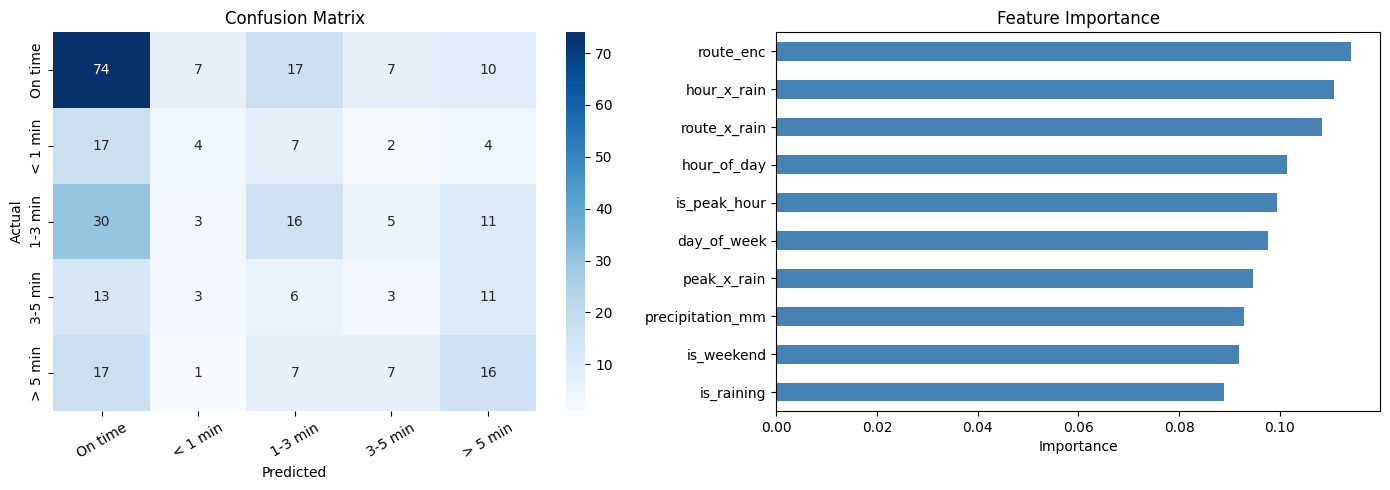

In [7]:
# ── 6. Confusion matrix & feature importance ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=30)

imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [8]:
# ── 7. Cross-validation ───────────────────────────────────────────────────────
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold: {cv_scores.round(4)}')

5-Fold CV Accuracy: 0.3607 ± 0.0601
Per-fold: [0.3758 0.2458 0.367  0.3973 0.4175]


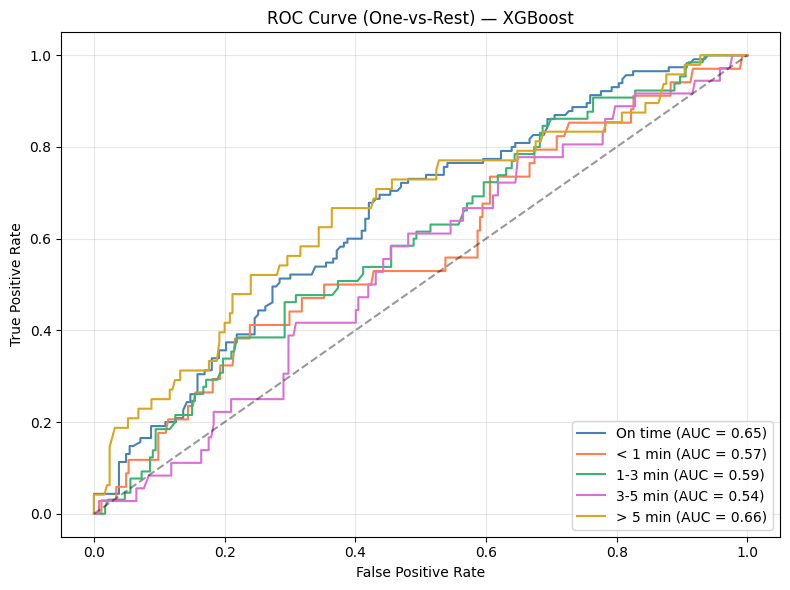

In [9]:
# ── 8. ROC curve (one-vs-rest) ────────────────────────────────────────────────
y_test_bin  = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
y_proba_all = model.predict_proba(X_test)

colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'goldenrod']
plt.figure(figsize=(8, 6))
for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_all[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) — XGBoost')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Additional Test: 3-Class Classification

AUC scores from the 5-class model ranged from 0.54–0.66, barely above random. 
The middle classes (< 1 min, 3-5 min) had too few samples (~170 each) to learn meaningful patterns.

**Merging into 3 classes:**
| Class | Label | Condition |
|---|---|---|
| 0 | On time | delay ≤ 0 min |
| 1 | Slightly late | 0 < delay ≤ 3 min |
| 2 | Late | delay > 3 min |

In [10]:
# ── 3-class label ─────────────────────────────────────────────────────────────
CLASS_NAMES_3 = ['On time', 'Slightly late', 'Late']

def delay_class_3(d):
    if d <= 0:   return 0
    elif d <= 3: return 1
    else:        return 2

df['delay_class_3'] = df['delay_min'].apply(delay_class_3)
print('3-class distribution:')
print(df['delay_class_3'].map(dict(enumerate(CLASS_NAMES_3))).value_counts().reindex(CLASS_NAMES_3))

X3 = df[FEATURES]
y3 = df['delay_class_3']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

model3 = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42
)
model3.fit(X3_train, y3_train)
y3_pred = model3.predict(X3_test)

print('\n=== Classification Report (3-class) ===')
print(classification_report(y3_test, y3_pred, target_names=CLASS_NAMES_3))

3-class distribution:
delay_class_3
On time          572
Slightly late    491
Late             423
Name: count, dtype: int64

=== Classification Report (3-class) ===
               precision    recall  f1-score   support

      On time       0.46      0.54      0.50       115
Slightly late       0.32      0.31      0.31        98
         Late       0.44      0.35      0.39        85

     accuracy                           0.41       298
    macro avg       0.41      0.40      0.40       298
 weighted avg       0.41      0.41      0.41       298



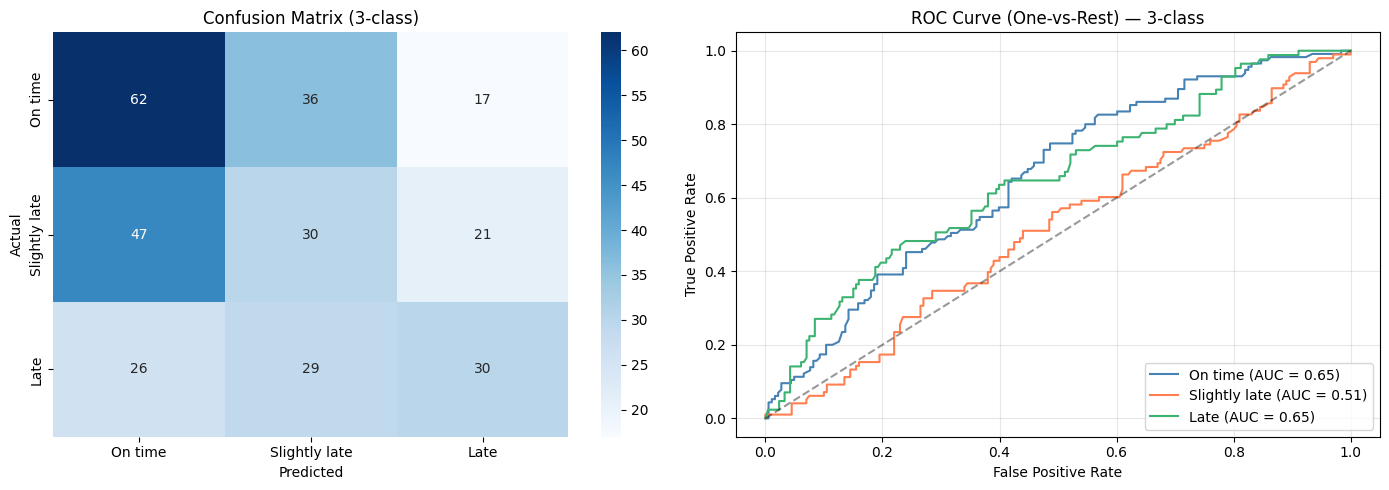

In [11]:
# ── Confusion matrix & ROC (3-class) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm3 = confusion_matrix(y3_test, y3_pred)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES_3, yticklabels=CLASS_NAMES_3)
axes[0].set_title('Confusion Matrix (3-class)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

y3_test_bin  = label_binarize(y3_test, classes=[0, 1, 2])
y3_proba_all = model3.predict_proba(X3_test)

colors = ['steelblue', 'coral', 'mediumseagreen']
for i, (name, color) in enumerate(zip(CLASS_NAMES_3, colors)):
    fpr, tpr, _ = roc_curve(y3_test_bin[:, i], y3_proba_all[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, label=f'{name} (AUC = {roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (One-vs-Rest) — 3-class')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Improvement Attempt: Binary Classification + SMOTE

3-class and 5-class models showed AUC close to random. Two strategies to improve:
1. **Binary classification** — simplify to 'On time (≤ 0 min)' vs 'Delayed (> 0 min)'
2. **SMOTE** — synthetically oversample the minority class to balance training data

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score

# ── Binary label: delayed = delay > 0 ────────────────────────────────────────
df['is_delayed'] = (df['delay_min'] > 0).astype(int)
print('Binary distribution:')
print(df['is_delayed'].value_counts().rename({0: 'On time', 1: 'Delayed'}))

X_bin = df[FEATURES]
y_bin = df['is_delayed']

X_bin_train, X_bin_test, y_bin_train, y_bin_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# ── SMOTE on training set only ────────────────────────────────────────────────
sm = SMOTE(random_state=42)
X_bin_res, y_bin_res = sm.fit_resample(X_bin_train, y_bin_train)
print(f'\nAfter SMOTE — train size: {len(X_bin_res)} (balanced)')

# ── XGBoost binary ───────────────────────────────────────────────────────────
model_bin = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
)
model_bin.fit(X_bin_res, y_bin_res)
y_bin_pred  = model_bin.predict(X_bin_test)
y_bin_proba = model_bin.predict_proba(X_bin_test)[:, 1]

print('\n=== Classification Report (Binary + SMOTE) ===')
print(classification_report(y_bin_test, y_bin_pred, target_names=['On time', 'Delayed']))
print(f'ROC-AUC: {roc_auc_score(y_bin_test, y_bin_proba):.4f}')

In [ ]:
# ── Confusion matrix & ROC (binary) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_bin = confusion_matrix(y_bin_test, y_bin_pred)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['On time', 'Delayed'],
            yticklabels=['On time', 'Delayed'])
axes[0].set_title('Confusion Matrix (Binary + SMOTE)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_bin_test, y_bin_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Binary + SMOTE')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()